# THỐNG KÊ MÁY TÍNH VÀ ỨNG DỤNG (ĐTTX)

**Khoa Công nghệ Thông tin - ĐH Khoa học Tự nhiên TP. HCM ([fit@hcmus](https://www.fit.hcmus.edu.vn/))**

*Giảng viên: Vũ Quốc Hoàng (vqhoang@fit.hcmus.edu.vn)*

# LẬP TRÌNH VỚI AI (AI-ASSISTED PROGRAMMING)

**Nội dung**

* [Giới thiệu](#gioi_thieu)
* [Chặng A - Người viết, AI nhắc](#chang_a)
  * [Cấp độ 1 - Nhắc từ khóa, cú pháp](#nhac_tu_khoa)
  * [Cấp độ 2 - Nhắc lệnh](#nhac_lenh)
  * [Cấp độ 3 - Điền trước](#dien_truoc)
* [Chặng B - Người nói, AI viết](#chang_b)
  * [Cấp độ 4 - Ra lệnh bằng lời](#ra_lenh)
  * [Cấp độ 5 - Vibe coding](#vibe_coding)
* [Chặng C - Người cầm lái, tác tử làm](#chang_c)
  * [Cấp độ 6 - Vibe engineering](#vibe_engineering)
* [Tổng kết](#tong_ket)

**Tài liệu tham khảo**

* [Inline suggestions from GitHub Copilot in VS Code](https://code.visualstudio.com/docs/editing/ai-powered-suggestions)
* [AI features in VS Code cheat sheet](https://code.visualstudio.com/docs/agents/reference/ai-features-cheat-sheet)
* [Use custom instructions in VS Code](https://code.visualstudio.com/docs/agent-customization/custom-instructions)
* [Vibe coding (Wikipedia)](https://en.wikipedia.org/wiki/Vibe_coding)
* [Vibe engineering (Simon Willison)](https://simonwillison.net/2025/Oct/7/vibe-engineering/)
* Python: [rlcompleter](https://docs.python.org/3/library/rlcompleter.html), [tokenize](https://docs.python.org/3/library/tokenize.html), [doctest](https://docs.python.org/3/library/doctest.html)

**Chuẩn bị**: VS Code, Python và Jupyter Extension (xem Bài 0); tài khoản GitHub và [GitHub Copilot](https://github.com/features/copilot) (gói Free có giới hạn lượt dùng mỗi tháng); `git` cho Cấp độ 6. Có thể dùng Google Colab (có sẵn trợ lý Gemini) thay cho VS Code ở các cấp độ 1–5.

## <a name="gioi_thieu"/>Giới thiệu

Máy tính hỗ trợ người lập trình với vai trò ngày càng lớn: từ nhắc một **từ**, một **dòng**, một **khối lệnh**, đến viết cả **chương trình** và làm cả **dự án**. Có thể chia quá trình phát triển thành 3 chặng với 6 **cấp độ** hỗ trợ tăng dần. Đây không phải 6 bước làm lần lượt: ngày nay ta vẫn dùng song song cả 6 cấp độ, tùy việc.

| Chặng | Cấp độ | Máy làm gì | Người làm gì | Ví dụ | Xuất hiện |
|---|---|---|---|---|---|
| **A. Người viết, AI nhắc** | 1. Nhắc từ khóa, cú pháp | Liệt kê các tên hợp lệ (từ khóa, biến, hàm, phương thức) | Chọn | IntelliSense, phím Tab trong Jupyter | Từ thập niên 1990 |
| | 2. Nhắc lệnh | Dự đoán phần tiếp theo của câu lệnh | Nhận hoặc bỏ | Các bộ gợi ý dùng học máy | Khoảng 2018–2020 |
| | 3. Điền trước | Điền cả khối lệnh, cả hàm từ chữ ký, chú thích, ngữ cảnh | Viết trước ý định, duyệt từng gợi ý | GitHub Copilot (gợi ý mờ - *ghost text*) | Từ 2021 |
| **B. Người nói, AI viết** | 4. Ra lệnh bằng lời | Viết, giải thích, sửa code theo yêu cầu bằng ngôn ngữ tự nhiên | Ra lệnh rõ ràng, **đọc và quyết định** | Chatbot, Chat và *inline chat* trong VS Code | Phổ biến từ cuối 2022 (ChatGPT) |
| | 5. **Vibe coding** | Viết cả chương trình | Mô tả, chạy thử, thấy "ổn" là nhận — **không đọc code** | Chế độ Agent, chatbot | Thuật ngữ có từ 2025 |
| **C. Người cầm lái, tác tử làm** | 6. **Vibe engineering** | Lập kế hoạch, viết, chạy, tự sửa theo vòng lặp (**tác tử** - *agent*) | Đặc tả, kiểm thử, rà soát, chịu trách nhiệm | Chế độ Agent trong VS Code, Claude Code, Codex, Gemini CLI | Thuật ngữ có từ cuối 2025 |

Phần việc AI làm **tăng dần** qua 6 cấp độ. Nhưng mức kiểm soát của người thì **giảm dần tới vibe coding rồi tăng trở lại** ở vibe engineering: người không "buông tay nhiều hơn nữa" mà **cầm lái lại, ở quy mô lớn hơn** — vai trò chuyển từ *gõ code* sang *nghĩ, đặc tả và kiểm chứng*.

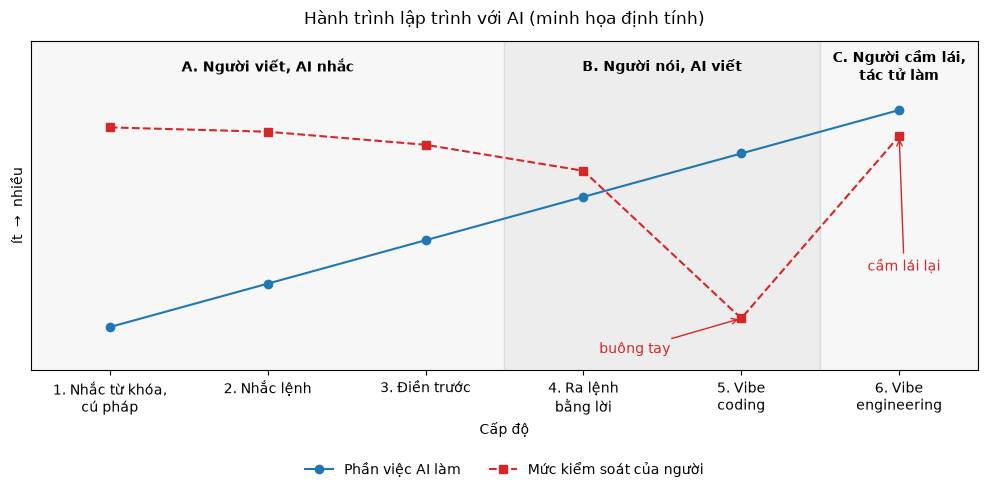

In [1]:
import matplotlib.pyplot as plt     # thư viện vẽ đồ thị (sẽ học ở Bài 5)

def ve_hanh_trinh():
    """Vẽ minh họa định tính: phần việc AI làm và mức kiểm soát của người qua 6 cấp độ."""
    buoc = ["1. Nhắc từ khóa,\ncú pháp", "2. Nhắc lệnh", "3. Điền trước",
            "4. Ra lệnh\nbằng lời", "5. Vibe\ncoding", "6. Vibe\nengineering"]
    x = range(1, 7)
    ai_lam = [1, 2, 3, 4, 5, 6]
    nguoi_kiem_soat = [5.6, 5.5, 5.2, 4.6, 1.2, 5.4]

    fig, ax = plt.subplots(figsize=(10, 5.2))
    chang = [(0.5, 3.5, "A. Người viết, AI nhắc"),
             (3.5, 5.5, "B. Người nói, AI viết"),
             (5.5, 6.5, "C. Người cầm lái,\ntác tử làm")]
    for i, (a, b, ten) in enumerate(chang):
        ax.axvspan(a, b, color="gray", alpha=0.06 if i % 2 == 0 else 0.14)
        ax.text((a + b) / 2, 7.0, ten, ha="center", va="center", fontweight="bold")
    ax.plot(x, ai_lam, "o-", color="tab:blue", label="Phần việc AI làm")
    ax.plot(x, nguoi_kiem_soat, "s--", color="tab:red", label="Mức kiểm soát của người")
    ax.annotate("buông tay", xy=(5, 1.2), xytext=(4.1, 0.4),
                arrowprops=dict(arrowstyle="->", color="tab:red"), color="tab:red")
    ax.annotate("cầm lái lại", xy=(6, 5.4), xytext=(5.8, 2.3),
                arrowprops=dict(arrowstyle="->", color="tab:red"), color="tab:red")
    ax.set_xticks(list(x), buoc)
    ax.set_xlabel("Cấp độ")
    ax.set_xlim(0.5, 6.5)
    ax.set_ylim(0, 7.6)
    ax.set_yticks([])
    ax.set_ylabel("ít  →  nhiều")
    ax.set_title("Hành trình lập trình với AI (minh họa định tính)", pad=12)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

ve_hanh_trinh()

**Lưu ý khi dùng AI trong môn học**: ghi rõ phần nào có dùng AI và dùng thế nào; phải hiểu và giải thích được code mình nộp; không đưa dữ liệu cá nhân, mật khẩu, khóa API lên công cụ AI.

## <a name="chang_a"/>Chặng A - Người viết, AI nhắc

Ở chặng này, người vẫn là **tác giả của từng dòng code**; máy chỉ gợi ý, với phạm vi lớn dần: một từ → một dòng → một khối lệnh.

### <a name="nhac_tu_khoa"/>Cấp độ 1 - Nhắc từ khóa, cú pháp

**Trải nghiệm**: trong ô code dưới đây, xóa phần `ctorial(5)` để còn `math.fa` rồi

* Jupyter: nhấn **Tab** để xem gợi ý; nhấn **Shift+Tab** bên trong dấu ngoặc để xem chữ ký hàm.
* VS Code: gợi ý tự hiện khi gõ (hoặc nhấn **Ctrl+Space**); rê chuột lên tên hàm để xem tài liệu.

In [ ]:
import math

math.factorial(5)

120

Bên trong, bộ gợi ý chỉ đơn giản là **tìm các tên có thật** bắt đầu bằng phần đã gõ. Module `rlcompleter` của Python làm đúng việc này:

In [3]:
import rlcompleter

bo_goi_y = rlcompleter.Completer({"math": math, "chuoi": "Hello"})

def goi_y_tu(tien_to):
    ds = []
    i = 0
    while True:
        g = bo_goi_y.complete(tien_to, i)   # gợi ý thứ i
        if g is None:
            return ds
        ds.append(g)
        i += 1

print(goi_y_tu("math.fa"))      # hàm trong module
print(goi_y_tu("chuoi.is"))     # phương thức của chuỗi
print(goi_y_tu("whi"))          # từ khóa

['math.fabs(', 'math.factorial(']
['chuoi.isalnum()', 'chuoi.isalpha()', 'chuoi.isascii()', 'chuoi.isdecimal()', 'chuoi.isdigit()', 'chuoi.isidentifier()', 'chuoi.islower()', 'chuoi.isnumeric()', 'chuoi.isprintable()', 'chuoi.isspace()', 'chuoi.istitle()', 'chuoi.isupper()']
['while ']


**Đặc trưng**: gợi ý **chính xác** (chỉ gồm tên có thật, dựa trên phân tích code), nhưng máy **không biết ý định** của người viết; mỗi lần chỉ giúp được một từ.

### <a name="nhac_lenh"/>Cấp độ 2 - Nhắc lệnh

Thay đổi quan trọng: từ "tên nào **hợp lệ**?" sang "người ta **thường viết gì tiếp theo**?". Câu hỏi thứ hai được trả lời bằng **thống kê trên kho mã nguồn** rất lớn — đúng tinh thần dùng máy tính để phân tích dữ liệu của môn học.

Demo: "huấn luyện" một mô hình dự đoán **token** (từ tố) tiếp theo bằng cách đếm tần suất trên chính mã nguồn thư viện chuẩn của Python (khoảng nửa triệu token, chạy vài giây).

In [4]:
import io
import pathlib
import sysconfig
import tokenize
from collections import Counter, defaultdict

BO_QUA = {tokenize.COMMENT, tokenize.NL, tokenize.INDENT, tokenize.DEDENT,
          tokenize.ENCODING, tokenize.ENDMARKER}

def tach_token(ma_nguon):
    ds = []
    for tk in tokenize.generate_tokens(io.StringIO(ma_nguon).readline):
        if tk.type in BO_QUA:
            continue
        elif tk.type == tokenize.NEWLINE:
            ds.append("⏎")                  # hết câu lệnh
        elif tk.type == tokenize.STRING:
            ds.append("'...'")              # gộp mọi chuỗi thành một loại
        else:
            ds.append(tk.string)
    return ds

N = 3                                       # nhìn tối đa 3 token phía trước
dem = defaultdict(Counter)                  # dem[ngữ cảnh][token tiếp theo] = số lần
thu_muc = pathlib.Path(sysconfig.get_paths()["stdlib"])
for tep in sorted(thu_muc.glob("*.py")):
    try:
        ds = tach_token(tep.read_text(encoding="utf-8"))
    except Exception:
        continue
    for i in range(len(ds) - N):
        ngu_canh = tuple(ds[i:i + N])
        for k in range(1, N + 1):           # đếm cho ngữ cảnh dài 1, 2, 3 token
            dem[ngu_canh[-k:]][ds[i + N]] += 1

print(f"Đã học {len(dem):,} ngữ cảnh khác nhau")

Đã học 257,650 ngữ cảnh khác nhau


In [5]:
def goi_y_tiep(ma, k=5):
    """Gợi ý k token tiếp theo (kèm xác suất) cho đoạn code ma (các token cách nhau bởi khoảng trắng)."""
    ds = ma.split()
    for j in range(N, 0, -1):               # ưu tiên ngữ cảnh dài nhất đã từng gặp
        c = dem.get(tuple(ds[-j:]))
        if c:
            tong = sum(c.values())
            return [(t, round(n / tong, 2)) for t, n in c.most_common(k)]
    return []

def nhac_lenh(ma, toi_da=12):
    """Hoàn thành câu lệnh: lặp lại việc chọn token có xác suất cao nhất."""
    ds = ma.split()
    while len(ds) < toi_da:
        g = goi_y_tiep(" ".join(ds), 1)
        if not g or g[0][0] == "⏎":
            break
        ds.append(g[0][0])
        if g[0][0] == ":":
            break
    return " ".join(ds)

for ma in ["import", "raise", "while", "for i in", "with open ("]:
    print(f"{ma!r:14} gợi ý: {goi_y_tiep(ma, 3)}")
    print(f"{'':14} nhắc lệnh: {nhac_lenh(ma)}")

'import'       gợi ý: [('sys', 0.07), ('warnings', 0.06), ('os', 0.05)]
               nhắc lệnh: import sys
'raise'        gợi ý: [('ValueError', 0.27), ('TypeError', 0.2), ('⏎', 0.08)]
               nhắc lệnh: raise ValueError ( '...' )
'while'        gợi ý: [('True', 0.28), ('1', 0.05), ('self', 0.04)]
               nhắc lệnh: while True :
'for i in'     gợi ý: [('range', 0.75), ('reversed', 0.03), ('self', 0.03)]
               nhắc lệnh: for i in range ( 0 , 0 , 0 , 0
'with open ('  gợi ý: [('filename', 0.24), ('file', 0.09), ('args', 0.07)]
               nhắc lệnh: with open ( filename , lineno , line ) :


**Nhận xét**

* Nhiều gợi ý rất "giống người viết": `for i in` → `range`, `while` → `True :`, `raise` → `ValueError (...)`.
* Nhưng ngữ cảnh quá ngắn nên có gợi ý **lặp vô nghĩa** hoặc **đúng cú pháp mà sai ý nghĩa** (ví dụ các dòng `for i in`, `with open (`; kết quả cụ thể tùy phiên bản Python). Máy chọn theo **xác suất**, không kiểm tra đúng sai.
* Các **mô hình ngôn ngữ lớn** (LLM) phía sau Copilot, ChatGPT, Gemini, Claude... dựa trên cùng ý tưởng "dự đoán token tiếp theo", nhưng dùng mạng nơ-ron hàng tỉ tham số, học trên kho dữ liệu khổng lồ và nhìn được ngữ cảnh rất dài. Chúng giỏi hơn rất nhiều, nhưng **vẫn có thể sai** — và thường sai một cách rất tự tin.

**Nhắc lệnh ngoài trình soạn thảo**: trong cửa sổ Terminal của VS Code, nhấn **Ctrl+I** và mô tả việc cần làm (ví dụ "liệt kê 5 file lớn nhất trong thư mục này") để AI đề xuất lệnh; đọc kỹ trước khi chạy.

### <a name="dien_truoc"/>Cấp độ 3 - Điền trước

Công cụ như GitHub Copilot hiển thị **gợi ý mờ** (*ghost text*) ngay tại con trỏ: có thể là cả dòng, cả khối lệnh hay cả hàm. AI nhìn cả code **phía trước và phía sau** con trỏ, tên file, các file đang mở.

| Thao tác trong VS Code | Phím |
|---|---|
| Nhận gợi ý / bỏ qua | **Tab** / **Esc** |
| Nhận từng từ của gợi ý | **Ctrl+→** |
| Xem gợi ý khác | **Alt+]** / **Alt+[** |
| Hỏi AI ngay trong code (*inline chat*) | **Ctrl+I** |

Ngoài ra, VS Code còn có **gợi ý sửa tiếp theo** (*next edit suggestions*): khi bạn sửa một chỗ (ví dụ đổi tên biến), AI đoán những chỗ khác cần sửa theo và cho phép nhấn Tab để đi tới.

**Tinh thần "điền trước"**: *người viết trước ý định* — tên hàm rõ nghĩa, chữ ký, chuỗi tài liệu (*docstring*) và **ví dụ** — *AI điền phần còn lại*. Viết trước càng rõ, AI điền càng đúng.

**Demo**: trong VS Code, gõ chữ ký và docstring của hàm dưới đây rồi xuống dòng để AI gợi ý thân hàm.

In [6]:
def dem_nguyen_am(s):
    """Đếm số nguyên âm trong chuỗi s."""
    # ↓ gợi ý điển hình của AI (minh họa)
    return sum(1 for c in s.lower() if c in "aeiou")

print(dem_nguyen_am("Hello"), dem_nguyen_am("Tiếng Việt"))

2 2


Với tiếng Anh thì đúng; nhưng "Tiếng Việt" có 4 nguyên âm (i, ế, i, ệ) mà hàm chỉ đếm được 2. AI không sai — ta **chưa nói rõ** mình cần gì.

Điền trước tốt hơn: mô tả rõ và cho **ví dụ** theo cú pháp [doctest](https://docs.python.org/3/library/doctest.html). Các ví dụ vừa giúp AI hiểu ý, vừa là **phép kiểm thử tự động**. Thử với thân hàm cũ:

In [7]:
import doctest

def dem_nguyen_am(s):
    """Đếm số nguyên âm tiếng Việt (a ă â e ê i o ô ơ u ư y, có dấu hay không) trong chuỗi s.

    >>> dem_nguyen_am("Hello")
    2
    >>> dem_nguyen_am("Tiếng Việt")
    4
    >>> dem_nguyen_am("ĐƯỜNG")
    2
    """
    return sum(1 for c in s.lower() if c in "aeiou")

doctest.run_docstring_examples(dem_nguyen_am, globals(), name="dem_nguyen_am")   # chỉ in ra các ví dụ sai

**********************************************************************
File "__main__", line 8, in dem_nguyen_am
Failed example:
    dem_nguyen_am("Tiếng Việt")
Expected:
    4
Got:
    2
**********************************************************************
File "__main__", line 10, in dem_nguyen_am
Failed example:
    dem_nguyen_am("ĐƯỜNG")
Expected:
    2
Got:
    0


Và gợi ý của AI khi đã có docstring rõ ràng (minh họa):

In [8]:
import unicodedata

def dem_nguyen_am(s):
    """Đếm số nguyên âm tiếng Việt (a ă â e ê i o ô ơ u ư y, có dấu hay không) trong chuỗi s.

    >>> dem_nguyen_am("Hello")
    2
    >>> dem_nguyen_am("Tiếng Việt")
    4
    >>> dem_nguyen_am("ĐƯỜNG")
    2
    """
    s = unicodedata.normalize("NFD", s.lower())    # tách dấu khỏi chữ: "ế" -> "e" + các dấu
    return sum(1 for c in s if c in "aeiouy")

doctest.run_docstring_examples(dem_nguyen_am, globals(), verbose=True, name="dem_nguyen_am")

Finding tests in dem_nguyen_am
Trying:
    dem_nguyen_am("Hello")
Expecting:
    2
ok
Trying:
    dem_nguyen_am("Tiếng Việt")
Expecting:
    4
ok
Trying:
    dem_nguyen_am("ĐƯỜNG")
Expecting:
    2
ok


**Đặc trưng**: nhanh và "thuận tay", người vẫn **kiểm soát từng dòng**. Nhưng dễ nhấn Tab theo quán tính — hãy đọc gợi ý trước khi nhận.

**Bài tập** *(sinh viên tự rèn luyện, có thể được điểm cộng trong giờ học trực tuyến)*: viết **trước** docstring với ít nhất 3 ví dụ cho hàm `chuan_hoa_ho_ten(s)` (bỏ khoảng trắng thừa, viết hoa chữ cái đầu mỗi từ), rồi để AI điền thân hàm và chạy doctest. Gợi ý đầu tiên của AI có đạt không? Bạn đã sửa docstring thế nào?

In [9]:
def chuan_hoa_ho_ten(s):
    """TODO: mô tả và thêm ít nhất 3 ví dụ

    >>> chuan_hoa_ho_ten("  nguyễn   văn  AN ")
    'Nguyễn Văn An'
    """
    # TODO: để AI điền

# doctest.run_docstring_examples(chuan_hoa_ho_ten, globals(), verbose=True)

## <a name="chang_b"/>Chặng B - Người nói, AI viết

Ở chặng này, người **mô tả bằng lời** và AI viết code. Khác biệt giữa Cấp độ 4 và Cấp độ 5 không nằm ở công cụ mà ở **thái độ**: người có đọc và hiểu code AI viết hay không.

### <a name="ra_lenh"/>Cấp độ 4 - Ra lệnh bằng lời

Đây là cách dùng AI mà nhiều người đã quen: hỏi và ra lệnh cho chatbot bằng ngôn ngữ tự nhiên. Trong VS Code có hai cách:

* **Inline chat**: chọn đoạn code, nhấn **Ctrl+I**, gõ lệnh (ví dụ "thêm kiểm tra đầu vào"); AI đề xuất thay đổi ngay trong code để bạn xem so sánh rồi nhận hoặc bỏ.
* **Chat**: hỏi đáp trong cửa sổ Chat (biểu tượng Chat trên thanh tiêu đề hoặc **Ctrl+Alt+I**).

Điểm cốt lõi của cấp độ này: người **đọc, hiểu và quyết định** với từng câu trả lời.

| Loại lệnh | Ví dụ |
|---|---|
| Giải thích | "Giải thích từng dòng đoạn code sau cho người mới học Python: ..." |
| Viết code | "Viết hàm ... Chỉ dùng ... Ví dụ: ... → ..." |
| Sửa lỗi | "Tôi dùng Python 3.x. Code: ... Lỗi: *(dán toàn bộ thông báo lỗi)*. Tôi muốn ... Nguyên nhân và cách sửa?" |
| Cải tiến | "Viết lại đoạn sau ngắn gọn hơn bằng list comprehension, giữ nguyên kết quả: ..." |
| Làm gia sư | "Đừng đưa lời giải. Hãy gợi ý từng bước để tôi tự viết code cho bài sau: ..." |

Một lệnh tốt thường có: **bối cảnh** (Python 3, notebook, đang học gì), **nhiệm vụ** cụ thể, **ràng buộc** (được dùng gì, không được dùng gì) và **ví dụ** đầu vào/đầu ra.

**Demo 1 - Giải thích.** Chạy lại ví dụ biểu thức chính quy ở Bài 2.1 (trên Python 3.12 trở lên sẽ có cảnh báo):

In [10]:
import re

text = """Theo lịch vạn niên dương lịch, năm 2025 được tính bắt đầu từ ngày 01/01/2025 đến hết ngày 31/12/2025. 
Còn theo lịch âm, năm 2025 là năm Ất Tỵ, tính từ ngày 29/01/2025 đến hết ngày 16/02/2026."""

date = "\d+/\d+/\d+"
print(re.findall(date, text))

['01/01/2025', '31/12/2025', '29/01/2025', '16/02/2026']


<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Dell Inspiron\AppData\Local\Temp\ipykernel_27580\3037550323.py:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  date = "\d+/\d+/\d+"


**Lệnh**:
> Tôi dùng Python 3.12. Giải thích biểu thức chính quy `"\d+/\d+/\d+"` cho người mới học, và vì sao Python báo `SyntaxWarning: invalid escape sequence '\d'`?

**Ý chính của một câu trả lời tốt** (so sánh với câu trả lời AI đưa cho bạn):
* `\d` là một chữ số, `+` là "một hoặc nhiều lần", `/` là chính ký tự `/` → khớp các chuỗi dạng *số/số/số*.
* Trong chuỗi thường, `\` bắt đầu một ký tự thoát (như `\n`); `\d` không phải ký tự thoát hợp lệ nên Python cảnh báo. Nên dùng **chuỗi thô** (*raw string*): `r"\d+/\d+/\d+"`.
* Hạn chế: mẫu này khớp cả những "ngày" vô lý như `99/99/2025`.

**Demo 2 - Viết code theo lệnh, rồi ra lệnh tiếp.**

> Viết hàm Python `tach_ngay(van_ban)` trả về danh sách các bộ `(ngày, tháng, năm)` kiểu `int` của các ngày dạng `dd/mm/yyyy` trong văn bản. Chỉ dùng module `re`. Ví dụ: `tach_ngay("từ 01/01/2025 đến 31/12/2025")` trả về `[(1, 1, 2025), (31, 12, 2025)]`.

In [11]:
# ↓ câu trả lời điển hình của AI (minh họa)
def tach_ngay(van_ban):
    mau = r"\b(\d{1,2})/(\d{1,2})/(\d{4})\b"      # nhóm (...) để lấy riêng ngày, tháng, năm
    return [(int(d), int(m), int(y)) for d, m, y in re.findall(mau, van_ban)]

# Người đọc code, rồi kiểm tra với ví dụ trong lệnh và dữ liệu của mình
assert tach_ngay("từ 01/01/2025 đến 31/12/2025") == [(1, 1, 2025), (31, 12, 2025)]
thong_bao = "Hạn nộp bài 1 là 15/10/2026, bài 2 là 31/02/2026 (gõ nhầm), thi cuối kỳ 5/1/2027."
print(tach_ngay(text))
print(tach_ngay(thong_bao))

[(1, 1, 2025), (31, 12, 2025), (29, 1, 2025), (16, 2, 2026)]
[(15, 10, 2026), (31, 2, 2026), (5, 1, 2027)]


Đọc kết quả, ta thấy `31/02/2026` (không tồn tại) vẫn được nhận. Không cần làm lại từ đầu, chỉ cần **ra lệnh tiếp**:

> Bỏ qua các ngày không hợp lệ như 31/02/2026. Được dùng thêm module `datetime`.

In [12]:
# ↓ câu trả lời điển hình của AI (minh họa)
from datetime import date as Ngay

def tach_ngay(van_ban):
    kq = []
    for d, m, y in re.findall(r"\b(\d{1,2})/(\d{1,2})/(\d{4})\b", van_ban):
        try:
            Ngay(int(y), int(m), int(d))       # báo ValueError nếu ngày không tồn tại
        except ValueError:
            continue
        kq.append((int(d), int(m), int(y)))
    return kq

assert tach_ngay("từ 01/01/2025 đến 31/12/2025") == [(1, 1, 2025), (31, 12, 2025)]
print(tach_ngay(thong_bao))

[(15, 10, 2026), (5, 1, 2027)]


**Đặc trưng**: AI viết nhanh, người vẫn **đọc, hiểu, kiểm tra** và dẫn dắt bằng các lệnh tiếp theo. Kỹ năng cần rèn: ra lệnh rõ ràng, đọc hiểu code, và nghi ngờ đúng lúc (AI có thể dùng cú pháp cũ, "bịa" hàm không tồn tại, hoặc hiểu sai yêu cầu mơ hồ).

**Bài tập** *(sinh viên tự rèn luyện, có thể được điểm cộng trong giờ học trực tuyến)*: chọn một bài tập trong Bài 1 – Bài 2 mà bạn chưa làm được. Ra lệnh cho AI làm **gia sư** ("Đừng đưa lời giải. Hãy gợi ý từng bước..."), tự viết code theo các gợi ý, rồi ghi lại các gợi ý hữu ích nhất.

In [13]:
# TODO:

### <a name="vibe_coding"/>Cấp độ 5 - Vibe coding

Thuật ngữ **vibe coding** do Andrej Karpathy đưa ra đầu năm 2025. Có thể hiểu gọn: **ra lệnh bằng lời như Cấp độ 4 nhưng bỏ bước đọc code** — buông theo "cảm giác", nhận mọi thay đổi AI đề xuất mà không đọc, gặp lỗi thì dán thông báo lỗi cho AI; chương trình có vẻ chạy là được.

* **Phù hợp**: thử nghiệm ý tưởng, công cụ dùng một lần, khám phá thư viện mới, người chưa biết lập trình tạo công cụ nhỏ cho riêng mình.
* **Không phù hợp**: phần mềm cần tin cậy, cần bảo trì, xử lý dữ liệu thật, bài nộp — vì không ai thực sự biết code làm gì.

Nếu bạn đọc, hiểu và kiểm thử mọi dòng AI viết thì đó **không còn** là vibe coding (Simon Willison).

**Demo** (VS Code): mở cửa sổ Chat (biểu tượng Chat trên thanh tiêu đề hoặc **Ctrl+Alt+I**), chọn chế độ **Agent**, gõ:

> Viết file `doc_so.py` có hàm `doc_so(n)` đọc số nguyên thành chữ tiếng Việt, ví dụ 123 → "một trăm hai mươi ba".

Chấp nhận (*Keep*) mọi thay đổi mà không đọc, chạy thử vài số, thấy ổn là xong. Ô dưới đây tạo lại một kết quả điển hình (minh họa) trong thư mục `doc_so_demo`.

In [14]:
import importlib
import os
import sys

os.makedirs("doc_so_demo", exist_ok=True)
sys.path.insert(0, os.path.abspath("doc_so_demo"))

In [15]:
%%writefile doc_so_demo/doc_so.py
# doc_so.py - do AI tạo theo kiểu "vibe coding" (minh họa)

CHU_SO = ["không", "một", "hai", "ba", "bốn", "năm", "sáu", "bảy", "tám", "chín"]
DON_VI = ["", " nghìn", " triệu", " tỷ"]


def doc_ba_so(n):
    """Đọc số có tối đa 3 chữ số."""
    tram, chuc, dv = n // 100, (n // 10) % 10, n % 10
    kq = []
    if tram > 0:
        kq.append(CHU_SO[tram] + " trăm")
    if chuc > 1:
        kq.append(CHU_SO[chuc] + " mươi")
    elif chuc == 1:
        kq.append("mười")
    elif tram > 0 and dv > 0:
        kq.append("linh")
    if dv > 0:
        if dv == 1 and chuc > 1:
            kq.append("mốt")
        elif dv == 5 and chuc > 0:
            kq.append("lăm")
        else:
            kq.append(CHU_SO[dv])
    return " ".join(kq)


def doc_so(n):
    """Đọc số nguyên n thành chữ tiếng Việt."""
    if n == 0:
        return "không"
    kq = []
    i = 0
    while n > 0:
        nhom = n % 1000
        if nhom > 0:
            kq.insert(0, doc_ba_so(nhom) + DON_VI[i])
        n //= 1000
        i += 1
    return " ".join(kq)

Overwriting doc_so_demo/doc_so.py


In [16]:
import doc_so as ds
importlib.reload(ds)            # nạp lại nếu file vừa thay đổi

for n in [123, 15, 21, 105, 2025, 1_000_000]:
    print(f"{n:>9,} → {ds.doc_so(n)}")

      123 → một trăm hai mươi ba
       15 → mười lăm
       21 → hai mươi mốt
      105 → một trăm linh năm
    2,025 → hai nghìn hai mươi lăm
1,000,000 → một triệu


Trông rất ổn! Nhưng: hàm này **đúng với mọi số** chưa? Đọc năm 2025 là "hai nghìn hai mươi lăm" hay "hai nghìn không trăm hai mươi lăm"? Số 24 đọc "hai mươi bốn" hay "hai mươi tư"? Ta **chưa từng nói rõ**, và cũng **chưa kiểm tra**. → Cấp độ 6.

## <a name="chang_c"/>Chặng C - Người cầm lái, tác tử làm

Tác tử lập trình tự lập kế hoạch, sửa nhiều file, chạy lệnh và tự sửa lỗi theo vòng lặp. Càng giao nhiều việc, người càng phải **cầm lái chặt**.

### <a name="vibe_engineering"/>Cấp độ 6 - Vibe engineering

Cuối năm 2025, Simon Willison đề xuất thuật ngữ **vibe engineering** cho đầu kia của phổ: người làm nghề dùng AI và các **tác tử lập trình** (*coding agent*) để tăng tốc, nhưng **vẫn hoàn toàn chịu trách nhiệm** về phần mềm mình làm ra. Hiện nay cách làm này thường được gọi là **agentic engineering**.

| | Vibe coding | Vibe engineering |
|---|---|---|
| Mục tiêu | Chạy được, nhanh | Đúng, tin cậy, bảo trì được |
| Yêu cầu | Mô tả chung chung | **Đặc tả** rõ, có quy ước và ví dụ |
| Kiểm tra | Thử vài lần bằng tay | **Kiểm thử tự động**, viết trước khi giao việc |
| Đọc code | Không | **Rà soát** mọi thay đổi |
| Lịch sử | Không | **git**: lưu từng bước, hoàn tác được |
| Vai trò người | "Đặt hàng" | Lập kế hoạch, kiểm soát, chịu trách nhiệm |

Willison nhận xét AI **khuếch đại** các thói quen tốt của kỹ sư phần mềm: lập kế hoạch trước, kiểm thử tự động, tài liệu đầy đủ, quản lý phiên bản, rà soát code, kiểm thử thủ công các trường hợp biên, và biết việc nào nên giao cho AI. Ông cũng cảnh báo tác tử giống những "thực tập sinh" sẵn sàng **"ăn gian"** khi có cơ hội (ví dụ sửa luôn phép kiểm thử cho "qua").

**Demo**: làm lại `doc_so` theo cách chặt chẽ, trong một thư mục dự án nhỏ mở được bằng VS Code.

**Bước 1 - Đặc tả bằng ví dụ** (kiểm thử viết **trước**, và **không giao cho AI sửa**):

In [17]:
%%writefile doc_so_demo/test_doc_so.py
"""Đặc tả bằng ví dụ cho hàm doc_so. Tác tử KHÔNG được sửa file này.
Chạy: python test_doc_so.py   (hoặc: pytest)"""
from doc_so import doc_so

CA_KIEM_THU = {
    0: "không", 5: "năm", 10: "mười", 11: "mười một", 14: "mười bốn", 15: "mười lăm",
    20: "hai mươi", 21: "hai mươi mốt", 24: "hai mươi tư", 25: "hai mươi lăm",
    55: "năm mươi lăm", 100: "một trăm", 101: "một trăm linh một",
    105: "một trăm linh năm", 110: "một trăm mười", 115: "một trăm mười lăm",
    999: "chín trăm chín mươi chín", 1000: "một nghìn",
    1005: "một nghìn không trăm linh năm", 1050: "một nghìn không trăm năm mươi",
    2026: "hai nghìn không trăm hai mươi sáu", 15000: "mười lăm nghìn",
    21000: "hai mươi mốt nghìn", 100000: "một trăm nghìn", 1000000: "một triệu",
    1000005: "một triệu không trăm linh năm",
    1001000: "một triệu không trăm linh một nghìn",
    1234567: "một triệu hai trăm ba mươi tư nghìn năm trăm sáu mươi bảy",
    10**9: "một tỷ",
    999999999999: "chín trăm chín mươi chín tỷ chín trăm chín mươi chín triệu "
                  "chín trăm chín mươi chín nghìn chín trăm chín mươi chín",
}
NGOAI_PHAM_VI = [-1, 10**12]        # phải báo lỗi ValueError


def test_cac_vi_du():
    for n, mong_doi in CA_KIEM_THU.items():
        assert doc_so(n) == mong_doi, f"doc_so({n}) = {doc_so(n)!r}"


def test_ngoai_pham_vi():
    for n in NGOAI_PHAM_VI:
        try:
            doc_so(n)
        except ValueError:
            continue
        raise AssertionError(f"doc_so({n}) phải báo ValueError")


if __name__ == "__main__":
    sai = 0
    for n, mong_doi in CA_KIEM_THU.items():
        try:
            thuc_te = doc_so(n)
        except Exception as e:
            thuc_te = f"<lỗi {type(e).__name__}>"
        if thuc_te != mong_doi:
            sai += 1
            print(f"SAI: doc_so({n}) = {thuc_te!r}, mong đợi {mong_doi!r}")
    for n in NGOAI_PHAM_VI:
        try:
            doc_so(n)
            sai += 1
            print(f"SAI: doc_so({n}) không báo ValueError")
        except ValueError:
            pass
        except Exception as e:
            sai += 1
            print(f"SAI: doc_so({n}) báo {type(e).__name__} thay vì ValueError")
    tong = len(CA_KIEM_THU) + len(NGOAI_PHAM_VI)
    print(f"Kết quả: {tong - sai}/{tong} ca kiểm thử đạt.")

Overwriting doc_so_demo/test_doc_so.py


**Bước 2 - Tài liệu cho tác tử**: file `AGENTS.md` ở thư mục gốc dự án được VS Code (và nhiều công cụ khác) tự động đưa vào mọi yêu cầu gửi tác tử. Đây là nơi ghi **quy ước** và **luật làm việc**.

In [18]:
%%writefile doc_so_demo/AGENTS.md
# Hướng dẫn cho tác tử AI

## Mục tiêu
Hàm `doc_so(n)` trong `doc_so.py` đọc số nguyên thành chữ tiếng Việt.

## Đặc tả và quy ước
- Phạm vi: số nguyên 0 <= n < 10**12; ngoài phạm vi thì báo `ValueError`.
- Dùng "nghìn" (không dùng "ngàn"), "linh" (không dùng "lẻ"), "tỷ".
- Sau "mươi": 1 đọc là "mốt", 4 đọc là "tư", 5 đọc là "lăm". Sau "mười": 5 đọc là "lăm".
- Nhóm 3 chữ số không đứng đầu thì đọc đủ hàng trăm: 1005 là "một nghìn không trăm linh năm".
- Nhóm bằng 0 thì bỏ qua: 1000005 là "một triệu không trăm linh năm".
- Các ví dụ trong `test_doc_so.py` là đặc tả chính thức.

## Luật làm việc
- Chỉ dùng thư viện chuẩn của Python.
- KHÔNG sửa `test_doc_so.py`. Nếu cho rằng một ca kiểm thử sai, dừng lại và giải thích.
- Không "mã hóa cứng" kết quả cho từng ca kiểm thử.
- Nêu kế hoạch ngắn gọn trước khi sửa code.
- Sau mỗi thay đổi, chạy `python test_doc_so.py` và báo kết quả.

Overwriting doc_so_demo/AGENTS.md


**Bước 3 - Chạy kiểm thử trên bản vibe coding**:

In [19]:
import subprocess

def chay_kiem_thu():
    kq = subprocess.run([sys.executable, "test_doc_so.py"], cwd="doc_so_demo",
                        capture_output=True, text=True, encoding="utf-8",
                        env={**os.environ, "PYTHONIOENCODING": "utf-8"})
    print(kq.stdout + kq.stderr)

chay_kiem_thu()

SAI: doc_so(24) = 'hai mươi bốn', mong đợi 'hai mươi tư'
SAI: doc_so(1005) = 'một nghìn năm', mong đợi 'một nghìn không trăm linh năm'
SAI: doc_so(1050) = 'một nghìn năm mươi', mong đợi 'một nghìn không trăm năm mươi'
SAI: doc_so(2026) = 'hai nghìn hai mươi sáu', mong đợi 'hai nghìn không trăm hai mươi sáu'
SAI: doc_so(1000005) = 'một triệu năm', mong đợi 'một triệu không trăm linh năm'
SAI: doc_so(1001000) = 'một triệu một nghìn', mong đợi 'một triệu không trăm linh một nghìn'
SAI: doc_so(1234567) = 'một triệu hai trăm ba mươi bốn nghìn năm trăm sáu mươi bảy', mong đợi 'một triệu hai trăm ba mươi tư nghìn năm trăm sáu mươi bảy'
SAI: doc_so(-1) không báo ValueError
SAI: doc_so(1000000000000) báo IndexError thay vì ValueError
Kết quả: 23/32 ca kiểm thử đạt.



Nhiều lỗi mà thử bằng tay không thấy. Đáng chú ý: `1005` bị đọc thành "một nghìn năm" — người nghe dễ hiểu thành **1500**!

**Bước 4 - Giao việc cho tác tử** (trong VS Code):

1. *File → Open Folder...* mở thư mục `doc_so_demo` (để `AGENTS.md` nằm ở thư mục gốc).
2. Lưu trạng thái ban đầu bằng git (Terminal hoặc biểu tượng *Source Control*):
   ```
   git init
   git add .
   git commit -m "Ban vibe coding + dac ta va kiem thu"
   ```
3. Mở Chat, chế độ **Agent**, gõ:
   > Đọc AGENTS.md. Chạy `python test_doc_so.py`, phân tích các ca sai, nêu kế hoạch rồi sửa `doc_so.py` cho đến khi mọi ca kiểm thử đạt.
4. Theo dõi tác tử lập kế hoạch → sửa code → chạy kiểm thử → tự sửa tiếp. Khi tác tử xin chạy lệnh trong Terminal, **đọc lệnh trước khi cho phép**.
5. **Rà soát** thay đổi (`git diff` hoặc giao diện so sánh của VS Code): tác tử có sửa file kiểm thử không? có mã hóa cứng không? code có đọc hiểu được không?
6. Hài lòng thì lưu: `git commit -am "Sua doc_so theo dac ta"`. Không hài lòng thì hoàn tác và hướng dẫn lại.

Ô dưới đây tạo lại một kết quả điển hình sau khi tác tử sửa (minh họa):

In [20]:
%%writefile doc_so_demo/doc_so.py
"""Đọc số nguyên thành chữ tiếng Việt (đặc tả: AGENTS.md và test_doc_so.py)."""

CHU_SO = ["không", "một", "hai", "ba", "bốn", "năm", "sáu", "bảy", "tám", "chín"]
DON_VI = ["", "nghìn", "triệu", "tỷ"]           # đơn vị của các nhóm 3 chữ số


def _doc_nhom(n, doc_du):
    """Trả về danh sách từ khi đọc nhóm 0 < n < 1000.
    doc_du=True (nhóm không đứng đầu): luôn đọc hàng trăm, kể cả "không trăm"."""
    tram, chuc, dv = n // 100, n // 10 % 10, n % 10
    tu = []
    if tram > 0 or doc_du:
        tu += [CHU_SO[tram], "trăm"]
    if chuc == 0:
        if dv > 0 and tu:                         # có hàng trăm phía trước: "linh"
            tu.append("linh")
    elif chuc == 1:
        tu.append("mười")
    else:
        tu += [CHU_SO[chuc], "mươi"]
    if dv > 0:
        if chuc >= 2 and dv == 1:
            tu.append("mốt")
        elif chuc >= 2 and dv == 4:
            tu.append("tư")
        elif chuc >= 1 and dv == 5:
            tu.append("lăm")
        else:
            tu.append(CHU_SO[dv])
    return tu


def doc_so(n):
    """Đọc số nguyên 0 <= n < 10**12 thành chữ tiếng Việt; ngoài phạm vi báo ValueError."""
    if not isinstance(n, int) or not 0 <= n < 10**12:
        raise ValueError(f"n phải là số nguyên trong [0, 10**12), nhận được {n!r}")
    if n == 0:
        return "không"
    nhom = []                                     # các nhóm 3 chữ số, từ phải sang trái
    while n > 0:
        nhom.append(n % 1000)
        n //= 1000
    tu = []
    for i in range(len(nhom) - 1, -1, -1):
        if nhom[i] == 0:
            continue                              # nhóm bằng 0: bỏ qua
        tu += _doc_nhom(nhom[i], doc_du=(i < len(nhom) - 1))
        if DON_VI[i]:
            tu.append(DON_VI[i])
    return " ".join(tu)

Overwriting doc_so_demo/doc_so.py


In [21]:
chay_kiem_thu()

Kết quả: 32/32 ca kiểm thử đạt.



**Bước 5 - Kiểm chứng thêm bằng sức mạnh máy tính**: 30 ca kiểm thử vẫn là ít. Cho máy thử **100.000 số ngẫu nhiên** và kiểm tra các tính chất mà mọi kết quả đúng đều phải thỏa.

In [22]:
import random
import time

importlib.reload(ds)
rng = random.Random(2026)
bat_dau = time.perf_counter()
for _ in range(100_000):
    n = rng.randrange(10 ** rng.randint(1, 12))          # số ngẫu nhiên đủ mọi độ lớn
    s = ds.doc_so(n)
    tu = s.split()
    assert s == " ".join(tu), (n, s)                     # không có khoảng trắng thừa
    assert "một mươi" not in s and "mười không" not in s, (n, s)
    assert all(t == "trăm" for t, sau in zip(tu, tu[1:]) if sau == "linh"), (n, s)
    assert n == 0 or tu[0] != "không", (n, s)            # không mở đầu bằng "không"
print(f"100.000 số ngẫu nhiên đều đạt, mất {time.perf_counter() - bat_dau:.2f} giây")

100.000 số ngẫu nhiên đều đạt, mất 0.67 giây


**Nhận xét**: phần *gõ code* đã giao cho AI; phần của người là **đặc tả** (quy ước, ví dụ), **kiểm thử**, **rà soát** và **quyết định**. Đó cũng là những kỹ năng cần rèn luyện nhất khi lập trình cùng AI.

**Bài tập** *(sinh viên tự rèn luyện, có thể được điểm cộng trong giờ học trực tuyến)*: mở rộng `doc_so` để đọc được **số âm** ("âm ...") và số lớn đến dưới $10^{15}$ (ví dụ 1500000000000 là "một nghìn năm trăm tỷ"). Làm theo quy trình vibe engineering: cập nhật `AGENTS.md`, thêm ít nhất 5 ca kiểm thử **trước**, commit, rồi mới giao cho tác tử; rà soát và commit kết quả. *Lưu ý*: yêu cầu mới mâu thuẫn với vài ca kiểm thử cũ — **bạn** (không phải tác tử) phải quyết định sửa chúng thế nào.

**Bài tập (thử thách)**: nhờ AI viết hàm ngược `chu_thanh_so(s)`, rồi kiểm chứng "khứ hồi" `chu_thanh_so(doc_so(n)) == n` với 100.000 số ngẫu nhiên. Nếu có ca sai, lỗi nằm ở hàm nào?

In [23]:
# TODO:

## <a name="tong_ket"/>Tổng kết

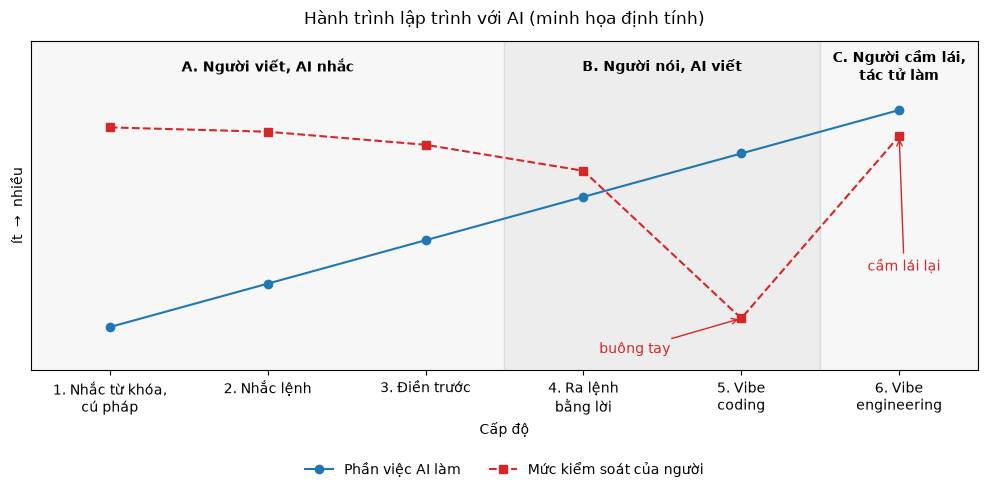

In [24]:
ve_hanh_trinh()

| Chặng | Cấp độ | Dùng khi | Điều cần nhớ |
|---|---|---|---|
| A. Người viết, AI nhắc | 1. Nhắc từ khóa, cú pháp | Mọi lúc | Chính xác nhưng chỉ giúp từng từ |
| | 2. Nhắc lệnh | Mọi lúc | Máy dự đoán theo xác suất: đúng thường gặp, không phải đúng chắc chắn |
| | 3. Điền trước | Viết hàm, khối lệnh quen thuộc | Viết trước tên, docstring, **ví dụ**; đọc trước khi nhấn Tab |
| B. Người nói, AI viết | 4. Ra lệnh bằng lời | Học, giải thích, viết và sửa từng phần | Lệnh rõ (bối cảnh, nhiệm vụ, ràng buộc, ví dụ); **đọc và kiểm tra** mọi câu trả lời |
| | 5. Vibe coding | Thử nghiệm, dùng một lần | Nhanh nhưng không ai thực sự biết code làm gì |
| C. Người cầm lái, tác tử làm | 6. Vibe engineering | Bài nộp, dữ liệu thật, phần mềm cần tin cậy | Đặc tả → kiểm thử → giao việc → rà soát → lưu phiên bản |

AI viết code ngày càng giỏi, nên giá trị của người lập trình càng nằm ở chỗ **biết mình cần gì** và **kiểm chứng được điều mình nhận**. Các buổi sau, ta sẽ dùng AI như một công cụ thường trực khi phân tích, xử lý dữ liệu với NumPy, pandas, Matplotlib...